# Irrigation Time-Series Model

This notebook builds a **time-aware multi-output classification model** for the smart agriculture setup.

**Contents:**
1. **Data loading & cleaning** — Same dataset as `Smart_Irrigation_Classification.ipynb`; chronological order preserved.
2. **EDA** — How sensor and nutrient values change over time; correlation matrices (raw and final features).
3. **Feature engineering** — Time features (month, hour, day_of_week, is_weekend) and `nutrient_index` (mean of N, P, K).
4. **Model** — Multi-output RandomForest; predictions for **watering pump** and **fan** ON/OFF per timestamp.
5. **Evaluation** — Metrics and confusion matrices at thresholds **0.8, 0.85, 0.9, 0.95**. Default threshold for deployment is **0.8** (80%).
6. **Export** — Full pipeline and config for the app.

**Goal:** Given a time and current sensor values, recommend which engines should be ON or OFF.

## 1. Imports and data loading

In [19]:
# 1. Data Loading & Initial Inspection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import warnings
import os

warnings.filterwarnings("ignore")

# Set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load data (same logic as Smart_Irrigation_Classification)
data_path = None
for fname in [
    "./data/irrigation.csv",
    "../data/irrigation.csv",
    "./data/IoTProcessed_Data.csv",
    "../data/IoTProcessed_Data.csv",
]:
    if os.path.exists(fname):
        data_path = fname
        break

if data_path is None:
    print("Data files found in ./data/:", os.listdir("./data/") if os.path.exists("./data/") else "No data folder")
    data_path = input("Enter CSV path: ")

df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
print(f"Column names: {list(df.columns)}")

print(data_path)

df.head()

Dataset shape: (37922, 13)
Column names: ['date', 'tempreature', 'humidity', 'water_level', 'N', 'P', 'K', 'Fan_actuator_OFF', 'Fan_actuator_ON', 'Watering_plant_pump_OFF', 'Watering_plant_pump_ON', 'Water_pump_actuator_OFF', 'Water_pump_actuator_ON']
../data/IoTProcessed_Data.csv


,date,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
0,2024-02-08 06:10:00,41,63,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
1,2024-02-08 06:15:00,41,59,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
2,2024-02-08 06:20:00,41,62,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
3,2024-02-08 06:05:00,40,60,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
4,2024-02-08 06:00:00,39,61,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0


## 2. Dataset info

In [20]:
# 2. Data Info

print("\n=== Dataset Info ===")
print(df.info())

print("\n=== Basic Statistics ===")
print(df.describe())


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37922 entries, 0 to 37921
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     37920 non-null  object 
 1   tempreature              37922 non-null  int64  
 2   humidity                 37922 non-null  int64  
 3   water_level              37922 non-null  int64  
 4   N                        37922 non-null  int64  
 5   P                        37922 non-null  int64  
 6   K                        37922 non-null  int64  
 7   Fan_actuator_OFF         37922 non-null  float64
 8   Fan_actuator_ON          37922 non-null  float64
 9   Watering_plant_pump_OFF  37922 non-null  float64
 10  Watering_plant_pump_ON   37922 non-null  float64
 11  Water_pump_actuator_OFF  37922 non-null  float64
 12  Water_pump_actuator_ON   37922 non-null  float64
dtypes: float64(6), int64(6), object(1)
memory usage: 3.8+ 

## 3. Cleaning and target construction

In [21]:
# 3. Data Cleaning & Target Construction (same as base notebook, plus time ordering)

# Check missing values
print("Missing values:")
missing = df.isnull().sum()
print(missing[missing > 0])
if missing.sum() == 0:
    print("No missing values found")

# Identify datetime-like columns and parse
date_cols = [col for col in df.columns if "date" in col.lower() or "time" in col.lower()]
if date_cols:
    date_col = date_cols[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    print(f"Parsed {date_col} to datetime")

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicates")

# IMPORTANT for time-series: sort by time so rows are in chronological order
if date_cols:
    df = df.sort_values(by=date_col).reset_index(drop=True)
    print(f"Sorted dataframe by {date_col} in ascending order")

# Identify and drop constant columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
if constant_cols:
    print(f"Dropping constant columns: {constant_cols}")
    df = df.drop(columns=constant_cols)

print(f"Shape after cleaning: {df.shape}")

# --- Prepare multi-output targets (same logic as base notebook) ---

# Ensure ON columns exist (derive from OFF if only OFF is present)
if "Watering_plant_pump_ON" not in df.columns and "Watering_plant_pump_OFF" in df.columns:
    df["Watering_plant_pump_ON"] = 1 - df["Watering_plant_pump_OFF"]
if "Fan_actuator_ON" not in df.columns and "Fan_actuator_OFF" in df.columns:
    df["Fan_actuator_ON"] = 1 - df["Fan_actuator_OFF"]

# Extract targets
if "Watering_plant_pump_ON" not in df.columns or "Fan_actuator_ON" not in df.columns:
    raise ValueError("Required target columns are missing. Please check dataset.")

y_irrigation = df["Watering_plant_pump_ON"]
y_fan = df["Fan_actuator_ON"]

print("Irrigation target distribution:")
print(y_irrigation.value_counts())

print("\nFan target distribution:")
print(y_fan.value_counts())

# Drop all actuator-related columns from df; they will not be used as features
actuator_keywords = ["actuator", "pump_on", "pump_off", "fan_", "_on", "_off"]
leakage_cols = [
    col
    for col in df.columns
    if any(kw in col.lower() for kw in actuator_keywords)
]

print(f"\nDropping actuator/leakage columns: {leakage_cols}")
df = df.drop(columns=leakage_cols)

print(f"Feature dataframe shape after dropping actuators: {df.shape}")
print(f"Remaining feature columns: {list(df.columns)}")

# Combine targets into a single DataFrame for multi-output
Y = pd.concat([y_irrigation.rename("irrigation"), y_fan.rename("fan")], axis=1)
print("\nCombined target shape:", Y.shape)
print("--")

Missing values:
date    2
dtype: int64
Parsed date to datetime
Removed 0 duplicates
Sorted dataframe by date in ascending order
Shape after cleaning: (37922, 13)
Irrigation target distribution:
Watering_plant_pump_ON
0.0    28900
1.0     9022
Name: count, dtype: int64

Fan target distribution:
Fan_actuator_ON
0.0    26161
1.0    11761
Name: count, dtype: int64

Dropping actuator/leakage columns: ['Fan_actuator_OFF', 'Fan_actuator_ON', 'Watering_plant_pump_OFF', 'Watering_plant_pump_ON', 'Water_pump_actuator_OFF', 'Water_pump_actuator_ON']
Feature dataframe shape after dropping actuators: (37922, 7)
Remaining feature columns: ['date', 'tempreature', 'humidity', 'water_level', 'N', 'P', 'K']

Combined target shape: (37922, 2)
--


## 4. Exploratory Data Analysis (EDA)

We visualize how **sensor and nutrient values** (excluding date and ON/OFF actuator variables) change over time, and we compute the **correlation matrix** for raw features.

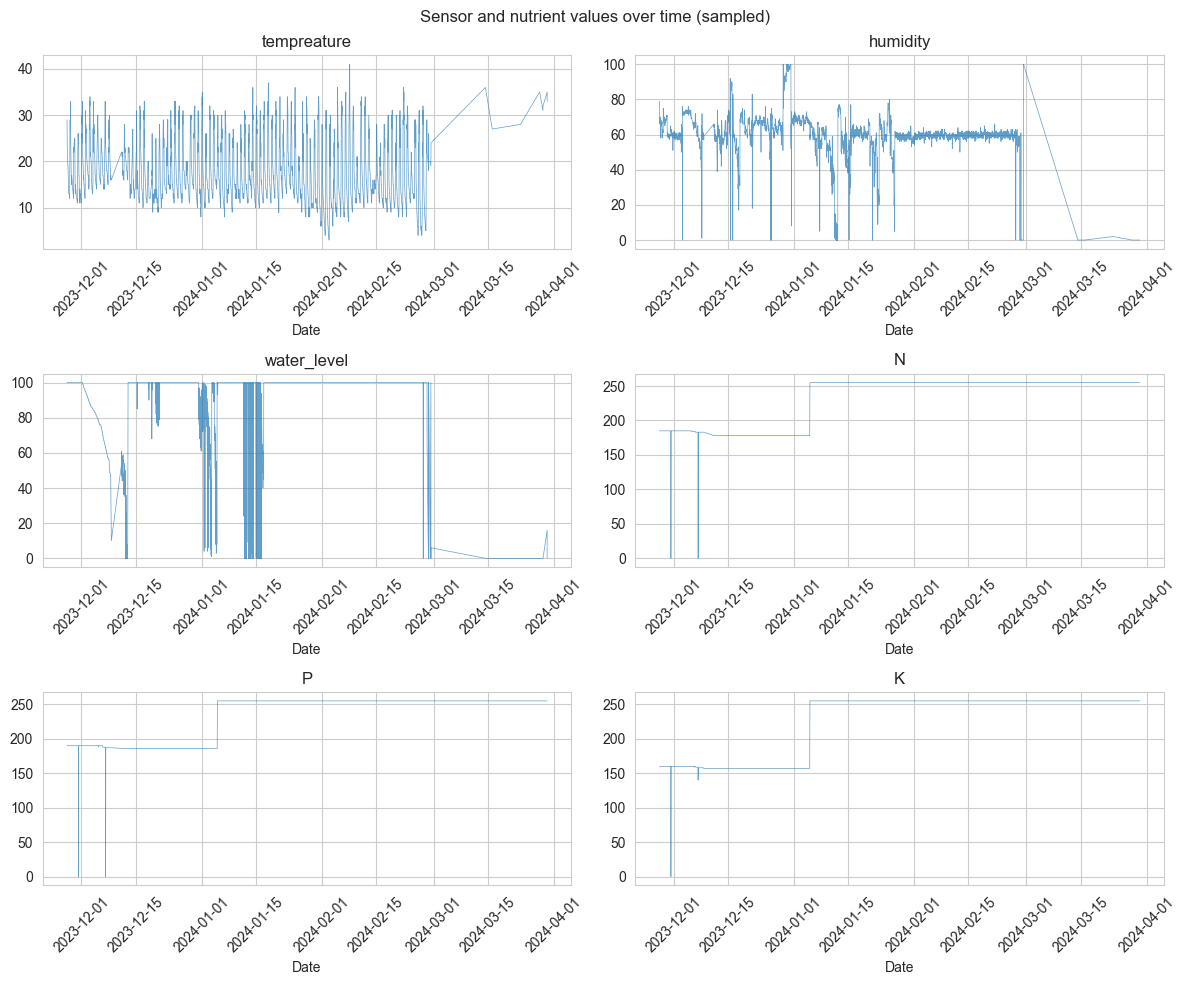

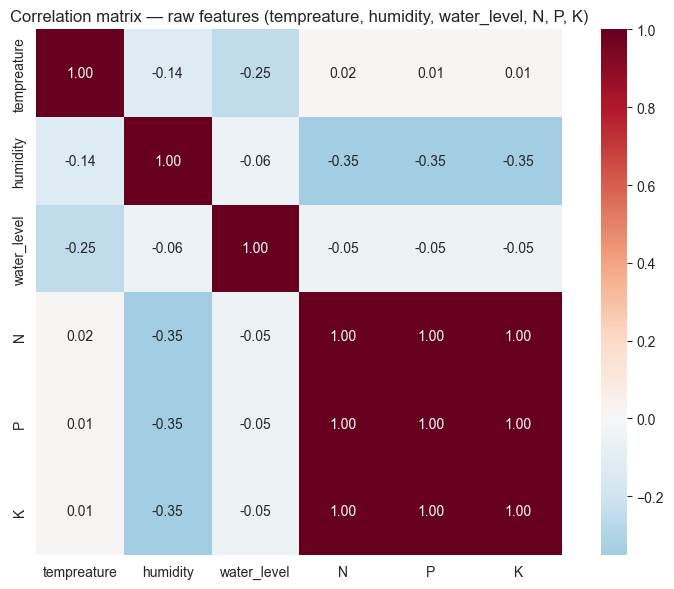

In [22]:
# Raw feature columns (sensors + nutrients; exclude date)
raw_feature_cols = ["tempreature", "humidity", "water_level", "N", "P", "K"]
# Ensure we have date for time axis (df still has it before feature engineering drops it)
df_plot = df[["date"] + raw_feature_cols].copy()
df_plot["date"] = pd.to_datetime(df_plot["date"])

# Sample for faster plotting if dataset is large
n_plot = min(5000, len(df_plot))
df_sampled = df_plot.iloc[::max(1, len(df_plot) // n_plot)]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(raw_feature_cols):
    axes[i].plot(df_sampled["date"], df_sampled[col], alpha=0.7, linewidth=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel("Date")
    axes[i].tick_params(axis="x", rotation=45)
plt.suptitle("Sensor and nutrient values over time (sampled)", fontsize=12)
plt.tight_layout()
plt.show()

# Correlation matrix: raw features (sensors + N, P, K)
raw_df = df[raw_feature_cols]
corr_raw = raw_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_raw, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix — raw features (tempreature, humidity, water_level, N, P, K)")
plt.tight_layout()
plt.show()

## 5. Feature engineering

Time features (month, hour, day_of_week, is_weekend) from date; `nutrient_index` = mean(N, P, K); N, P, K dropped.

In [23]:
# 4. Time Feature Engineering (same as base, time-aware)

# Extract time-based features from date column (including month for seasonality)
if date_cols:
    date_col = date_cols[0]
    df["month"] = df[date_col].dt.month
    df["hour"] = df[date_col].dt.hour
    df["day_of_week"] = df[date_col].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    print("Created time features: month, hour, day_of_week, is_weekend")

    # Drop the original date column
    df = df.drop(columns=[date_col])

# Create nutrient index from N, P, K (single feature to avoid multicollinearity)
nutrient_cols = [
    col
    for col in df.columns
    if col.upper() in ["N", "P", "K"]
    or any(n in col.upper() for n in ["NITRO", "PHOS", "POTASS"])
]
if len(nutrient_cols) >= 2:
    df["nutrient_index"] = df[nutrient_cols].mean(axis=1)
    print(f"Created: nutrient_index (mean of {nutrient_cols})")
    # Drop N, P, K so the model uses only nutrient_index
    df = df.drop(columns=nutrient_cols)
    print(f"Dropped raw nutrient columns: {nutrient_cols}")

print("\nFinal feature set shape:", df.shape)
print("Features:", list(df.columns))

df.head()

Created time features: month, hour, day_of_week, is_weekend
Created: nutrient_index (mean of ['N', 'P', 'K'])
Dropped raw nutrient columns: ['N', 'P', 'K']

Final feature set shape: (37922, 8)
Features: ['tempreature', 'humidity', 'water_level', 'month', 'hour', 'day_of_week', 'is_weekend', 'nutrient_index']


,tempreature,humidity,water_level,month,hour,day_of_week,is_weekend,nutrient_index
0,29,79,100,11.0,6.0,0.0,0,178.333333
1,29,78,100,11.0,6.0,0.0,0,178.333333
2,28,77,100,11.0,6.0,0.0,0,178.333333
3,28,75,100,11.0,6.0,0.0,0,178.333333
4,28,74,100,11.0,6.0,0.0,0,178.333333


In [24]:
# 5. Time-based Train/Test Split

# Use all current columns in df as features
feature_columns = list(df.columns)
X = df[feature_columns].copy()

# Y was created earlier and still aligned with df rows because we sorted before building features
print("Feature columns:", feature_columns)
print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Time-based split: first 80% of chronological data for training, last 20% for testing
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = Y.iloc[:split_idx], Y.iloc[split_idx:]

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

print("\nTarget distributions in training (irrigation, fan):")
print(y_train.apply(lambda col: col.value_counts()))

print("\nTarget distributions in test (irrigation, fan):")
print(y_test.apply(lambda col: col.value_counts()))

Feature columns: ['tempreature', 'humidity', 'water_level', 'month', 'hour', 'day_of_week', 'is_weekend', 'nutrient_index']
X shape: (37922, 8)
Y shape: (37922, 2)
Training set size: (30337, 8)
Test set size: (7585, 8)

Target distributions in training (irrigation, fan):
     irrigation    fan
0.0       21489  20366
1.0        8848   9971

Target distributions in test (irrigation, fan):
     irrigation   fan
0.0        7411  5795
1.0         174  1790


## 5a. Time-based train/test split

First 80% of chronological data for training, last 20% for testing (no shuffle).

## 5b. Correlation matrix — final model features

Correlation between the features actually used by the model (after replacing N, P, K with `nutrient_index` and adding time features).

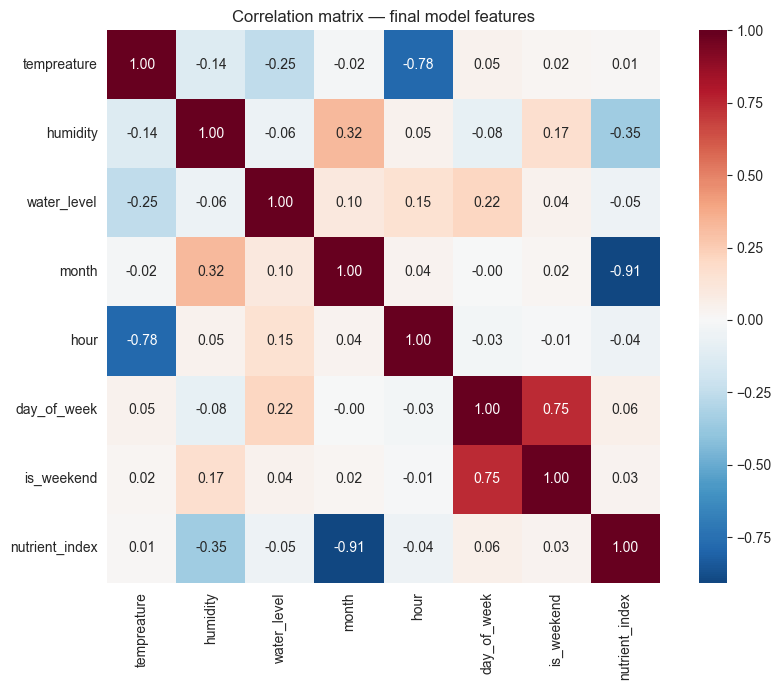

In [25]:
# Final feature set (same columns as df after feature engineering)
final_corr = df.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(final_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix — final model features")
plt.tight_layout()
plt.show()

In [26]:
# 6. Preprocessing Pipeline + Integrated Time-Series Model

from sklearn.pipeline import Pipeline
from sklearn import set_config
from sklearn.preprocessing import OneHotEncoder

# Identify numeric and categorical features
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Numeric transformer
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# ColumnTransformer
if categorical_features:
    categorical_transformer = Pipeline(steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )
else:
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
        ]
    )

# Build full pipeline including classifier
time_series_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    ))
])

print("\nFull preprocessing + model pipeline created")

# Fit full pipeline on time-ordered training data
time_series_model.fit(X_train, y_train)

# Expose processed data for downstream cells that expect X_train_processed / X_test_processed
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Pipeline fitted successfully")

# Enable sklearn diagram visualization
set_config(display="diagram")

time_series_model

Numeric features: ['tempreature', 'humidity', 'water_level', 'month', 'hour', 'day_of_week', 'nutrient_index']
Categorical features: []

Full preprocessing + model pipeline created
Pipeline fitted successfully


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tempreature', 'humidity',
                                                   'water_level', 'month',
                                                   'hour', 'day_of_week',
                                                   'nutrient_index'])])),
                ('classifier',
                 MultiOutputClassifier(estimator=RandomForestClassifier(n_estimators=200,
                                                                        n_jobs=-1,
                                                                        random_state=42)))])

## 6. Preprocessing and model training

ColumnTransformer (impute + scale) + MultiOutputClassifier(RandomForest). Fitted on raw `X_train`.

## 6b. Feature importance

Feature importances from the RandomForest classifier (one per target: irrigation and fan).

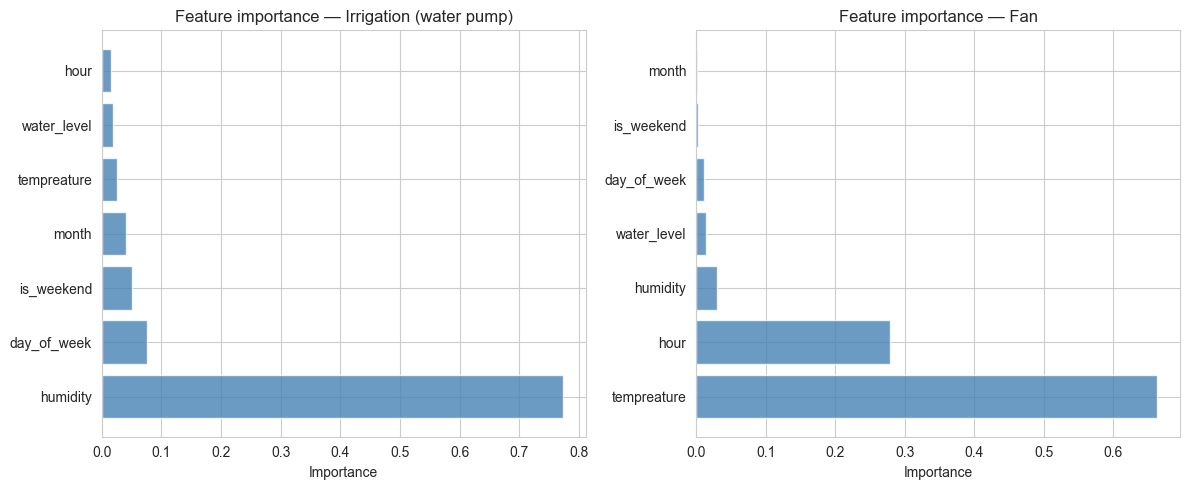

In [27]:
# Use the pipeline's classifier (before any later cell overwrites time_series_model)
# Pipeline structure: time_series_model.named_steps['classifier'] is MultiOutputClassifier
multi_out = time_series_model.named_steps["classifier"]
imp_irrigation = multi_out.estimators_[0].feature_importances_
imp_fan = multi_out.estimators_[1].feature_importances_
names = feature_columns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, imp, title in zip(axes, [imp_irrigation, imp_fan], ["Irrigation (water pump)", "Fan"]):
    order = np.argsort(imp)[::-1]
    ax.barh(np.array(names)[order], imp[order], color="steelblue", alpha=0.8)
    ax.set_title(f"Feature importance — {title}")
    ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [28]:
# 7. Time-aware Multi-output Model Training (RandomForest)

# Base classifier
base_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

# Multi-output wrapper to predict irrigation and fan simultaneously
time_series_model = MultiOutputClassifier(base_clf)

# Train on preprocessed, time-ordered training data
time_series_model.fit(X_train_processed, y_train)

print("Trained MultiOutput RandomForest model on time-ordered data.")

Trained MultiOutput RandomForest model on time-ordered data.


In [29]:
print(X.head())

   tempreature  humidity  water_level  month  hour  day_of_week  is_weekend  \
0           29        79          100   11.0   6.0          0.0           0   
1           29        78          100   11.0   6.0          0.0           0   
2           28        77          100   11.0   6.0          0.0           0   
3           28        75          100   11.0   6.0          0.0           0   
4           28        74          100   11.0   6.0          0.0           0   

   nutrient_index  
0      178.333333  
1      178.333333  
2      178.333333  
3      178.333333  
4      178.333333  


In [30]:
# Schedule for next 24 hours (same features as predict_engines_for_time)

def schedule_engines_next_24h(
    start_time,
    sensors,
    preprocessor=preprocessor,
    model=time_series_model,
    feature_columns=None,
    interval_minutes=60,
    threshold=0.5,
):
    """Build a list of (time, irrigation, fan) for the next 24 hours at interval_minutes."""
    if isinstance(start_time, str):
        ts = pd.to_datetime(start_time)
    else:
        ts = pd.to_datetime(start_time)

    n_val = sensors.get("N")
    p_val = sensors.get("P")
    k_val = sensors.get("K")
    nutrient_index = np.mean([n_val, p_val, k_val]) if all(v is not None for v in [n_val, p_val, k_val]) else 0.0

    slots = []
    t = ts
    end = t + pd.Timedelta(hours=24)
    while t < end:
        row = {
            "tempreature": sensors.get("tempreature"),
            "humidity": sensors.get("humidity"),
            "water_level": sensors.get("water_level"),
            "month": t.month,
            "hour": t.hour,
            "day_of_week": t.dayofweek,
            "is_weekend": int(t.dayofweek >= 5),
            "nutrient_index": nutrient_index,
        }
        X_row = pd.DataFrame([row])
        if feature_columns is not None:
            cols = [c for c in feature_columns if c in X_row.columns]
            X_row = X_row[cols]
        X_processed = preprocessor.transform(X_row)
        proba = model.predict_proba(X_processed)
        p_irrig = float(proba[0][0][1]) if proba[0] is not None else 0.0
        p_fan = float(proba[1][0][1]) if len(proba) > 1 and proba[1] is not None else 0.0
        irrigation = 1 if p_irrig >= threshold else 0
        fan = 1 if p_fan >= threshold else 0
        slots.append({"time": t.isoformat(), "irrigation": irrigation, "fan": fan})
        t = t + pd.Timedelta(minutes=interval_minutes)

    return slots


# Example: next 24h at hourly intervals
# print(schedule_engines_next_24h("2024-06-15 00:00:00", example_sensors, feature_columns=feature_columns, interval_minutes=60))

In [31]:
# 8. Helper Function: Predict Engines for a Given Time and Sensors

from datetime import datetime


def predict_engines_for_time(
    timestamp,
    sensors,
    preprocessor=preprocessor,
    model=time_series_model,
    feature_columns=None,
):
    """Given a timestamp and current sensor readings, return ON/OFF decisions.

    Parameters
    ----------
    timestamp : str or datetime
        The time for which to make the prediction (e.g. "2024-02-08 06:30:00").
    sensors : dict
        Dictionary with current sensor values, e.g.::

            {
                "tempreature": 25,
                "humidity": 60,
                "water_level": 90,
                "N": 230,
                "P": 240,
                "K": 220,
            }

    preprocessor : fitted sklearn ColumnTransformer
    model : fitted MultiOutputClassifier
    feature_columns : list[str] or None
        If provided, ensures the feature order matches training.
    """

    if isinstance(timestamp, str):
        ts = pd.to_datetime(timestamp)
    else:
        ts = pd.to_datetime(timestamp)

    # Nutrient index from N, P, K (user still inputs N, P, K)
    n_val = sensors.get("N")
    p_val = sensors.get("P")
    k_val = sensors.get("K")
    nutrient_index = np.mean([n_val, p_val, k_val]) if all(v is not None for v in [n_val, p_val, k_val]) else 0.0

    # Build a single-row DataFrame with the same features as training (no N, P, K columns)
    row = {
        "tempreature": sensors.get("tempreature"),
        "humidity": sensors.get("humidity"),
        "water_level": sensors.get("water_level"),
        "month": ts.month,
        "hour": ts.hour,
        "day_of_week": ts.dayofweek,
        "is_weekend": int(ts.dayofweek >= 5),
        "nutrient_index": nutrient_index,
    }

    X_new = pd.DataFrame([row])

    # Align columns to training feature order if provided
    if feature_columns is not None:
        # Keep only columns that exist and in the same order
        cols = [c for c in feature_columns if c in X_new.columns]
        X_new = X_new[cols]

    X_new_processed = preprocessor.transform(X_new)
    y_pred = model.predict(X_new_processed)[0]

    irrigation_pred, fan_pred = int(y_pred[0]), int(y_pred[1])

    decisions = {
        "irrigation": irrigation_pred,
        "fan": fan_pred,
        "irrigation_action": "TURN ON water pump" if irrigation_pred == 1 else "TURN OFF water pump",
        "fan_action": "TURN ON fan" if fan_pred == 1 else "TURN OFF fan",
    }

    return decisions


# Example usage (you can modify these values to test)
example_time = "2024-02-08 06:30:00"
example_sensors = {
    "tempreature": 25,
    "humidity": 60,
    "water_level": 90,
    "N": 230,
    "P": 240,
    "K": 220,
}

print("Example prediction for", example_time)
print(predict_engines_for_time(example_time, example_sensors, feature_columns=feature_columns))

Example prediction for 2024-02-08 06:30:00
{'irrigation': 0, 'fan': 1, 'irrigation_action': 'TURN OFF water pump', 'fan_action': 'TURN ON fan'}


=== Irrigation (Water Pump) ===
              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000      7411
         1.0     1.0000    1.0000    1.0000       174

    accuracy                         1.0000      7585
   macro avg     1.0000    1.0000    1.0000      7585
weighted avg     1.0000    1.0000    1.0000      7585

=== Fan Actuator ===
              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000      5795
         1.0     1.0000    1.0000    1.0000      1790

    accuracy                         1.0000      7585
   macro avg     1.0000    1.0000    1.0000      7585
weighted avg     1.0000    1.0000    1.0000      7585



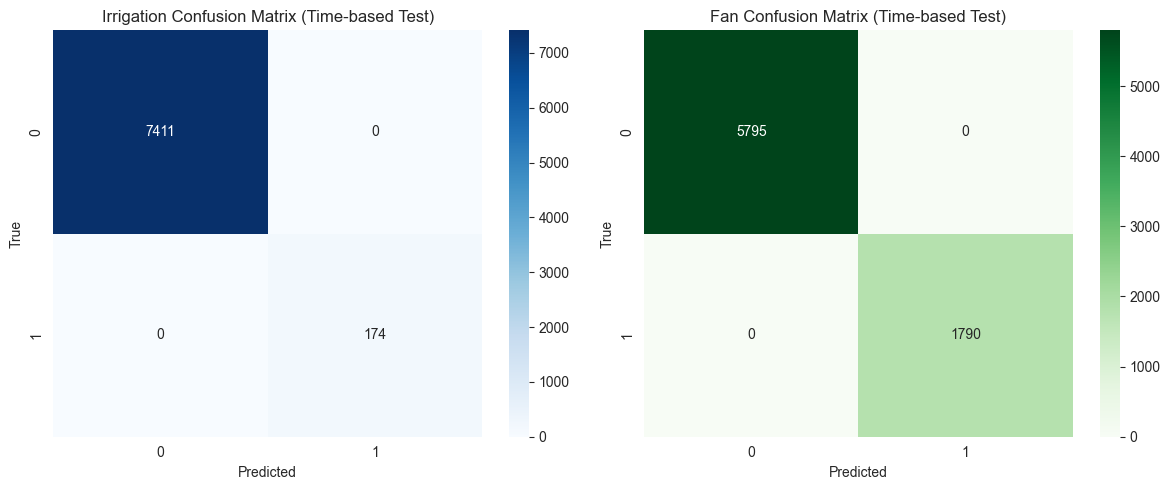

In [32]:
# 9. Evaluation on Future (Hold-out) Period

from sklearn.metrics import classification_report

# Predict on the time-based test set
y_pred = time_series_model.predict(X_test_processed)

# Split predictions by target
y_pred_irrigation = y_pred[:, 0]
y_pred_fan = y_pred[:, 1]

y_true_irrigation = y_test["irrigation"].values
y_true_fan = y_test["fan"].values

print("=== Irrigation (Water Pump) ===")
print(classification_report(y_true_irrigation, y_pred_irrigation, digits=4))

print("=== Fan Actuator ===")
print(classification_report(y_true_fan, y_pred_fan, digits=4))

# Confusion matrices
cm_irrigation = confusion_matrix(y_true_irrigation, y_pred_irrigation)
cm_fan = confusion_matrix(y_true_fan, y_pred_fan)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_irrigation, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Irrigation Confusion Matrix (Time-based Test)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_fan, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Fan Confusion Matrix (Time-based Test)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

## 10. Robustness Experiment: 10% Noisy Training Data

In this section we corrupt about **10% of the training feature rows** with random noise and retrain a new model.

- Only **training features** `X_train` are noised; the targets (`y_train`, `y_test`) and the entire test feature set (`X_test`) remain **clean**.
- We then evaluate this "noisy" model on the same clean time-based test set and compare the metrics to the baseline model from above.

In [33]:
# 10a. Create Noisy Version of the Training Features

import numpy as np

np.random.seed(42)

# Copy training features so we don't modify the original X_train
X_train_noisy = X_train.copy()

# Determine how many rows to corrupt (10% of training data)
noise_frac = 0.10
n_noisy = int(len(X_train_noisy) * noise_frac)
noisy_idx = np.random.choice(X_train_noisy.index, size=n_noisy, replace=False)

print(f"Corrupting {n_noisy} training rows out of {len(X_train_noisy)} (~{noise_frac*100:.0f}%).")

# Numeric feature columns to add noise to (same as baseline features)
num_cols = [
    "tempreature",
    "humidity",
    "water_level",
    "N",
    "P",
    "K",
    "hour",
    "day_of_week",
    "is_weekend",
    "nutrient_index",
]

# Keep only columns that actually exist (for safety)
num_cols = [c for c in num_cols if c in X_train_noisy.columns]

# Replace selected rows with random values within each column's training range
for col in num_cols:
    col_min, col_max = X_train_noisy[col].min(), X_train_noisy[col].max()
    X_train_noisy.loc[noisy_idx, col] = np.random.uniform(col_min, col_max, size=n_noisy)

X_train_noisy.head()

Corrupting 3033 training rows out of 30337 (~10%).


,tempreature,humidity,water_level,month,hour,day_of_week,is_weekend,nutrient_index
0,29.0,79.0,100.0,11.0,6.0,0.0,0.0,178.333333
1,29.0,78.0,100.0,11.0,6.0,0.0,0.0,178.333333
2,28.0,77.0,100.0,11.0,6.0,0.0,0.0,178.333333
3,28.0,75.0,100.0,11.0,6.0,0.0,0.0,178.333333
4,28.0,74.0,100.0,11.0,6.0,0.0,0.0,178.333333



Threshold: 0.8
Irrigation (Water Pump):
              precision    recall  f1-score   support

         0.0     0.9999    1.0000    0.9999      7411
         1.0     1.0000    0.9943    0.9971       174

    accuracy                         0.9999      7585
   macro avg     0.9999    0.9971    0.9985      7585
weighted avg     0.9999    0.9999    0.9999      7585



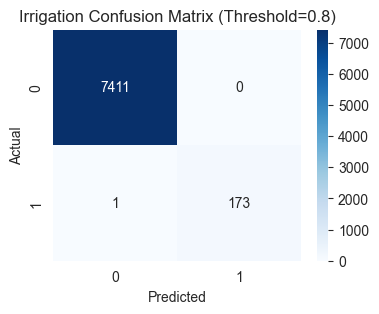

Fan actuator:
              precision    recall  f1-score   support

         0.0     0.9933    1.0000    0.9966      5795
         1.0     1.0000    0.9782    0.9890      1790

    accuracy                         0.9949      7585
   macro avg     0.9967    0.9891    0.9928      7585
weighted avg     0.9949    0.9949    0.9948      7585



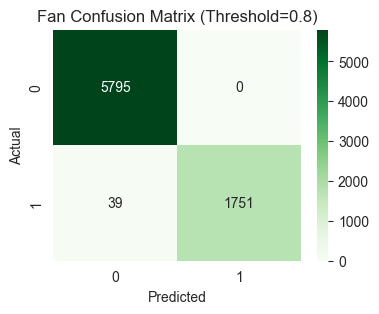


Threshold: 0.85
Irrigation (Water Pump):
              precision    recall  f1-score   support

         0.0     0.9887    1.0000    0.9943      7411
         1.0     1.0000    0.5115    0.6768       174

    accuracy                         0.9888      7585
   macro avg     0.9943    0.7557    0.8356      7585
weighted avg     0.9889    0.9888    0.9870      7585



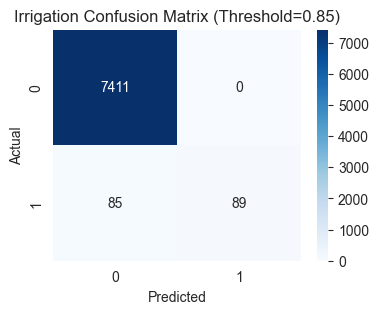

Fan actuator:
              precision    recall  f1-score   support

         0.0     0.9928    1.0000    0.9964      5795
         1.0     1.0000    0.9765    0.9881      1790

    accuracy                         0.9945      7585
   macro avg     0.9964    0.9883    0.9923      7585
weighted avg     0.9945    0.9945    0.9944      7585



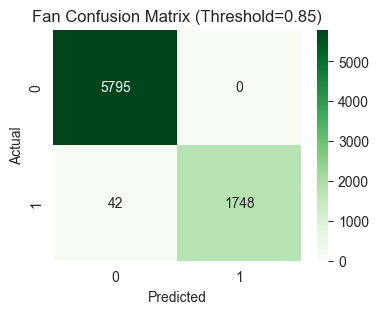


Threshold: 0.9
Irrigation (Water Pump):
              precision    recall  f1-score   support

         0.0     0.9774    1.0000    0.9886      7411
         1.0     1.0000    0.0172    0.0339       174

    accuracy                         0.9775      7585
   macro avg     0.9887    0.5086    0.5112      7585
weighted avg     0.9780    0.9775    0.9667      7585



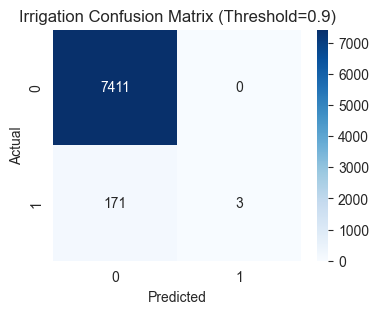

Fan actuator:
              precision    recall  f1-score   support

         0.0     0.9928    1.0000    0.9964      5795
         1.0     1.0000    0.9765    0.9881      1790

    accuracy                         0.9945      7585
   macro avg     0.9964    0.9883    0.9923      7585
weighted avg     0.9945    0.9945    0.9944      7585



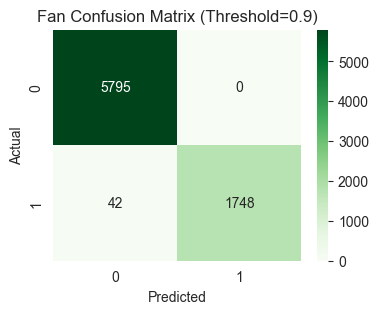


Threshold: 0.95
Irrigation (Water Pump):
              precision    recall  f1-score   support

         0.0     0.9773    1.0000    0.9885      7411
         1.0     1.0000    0.0115    0.0227       174

    accuracy                         0.9773      7585
   macro avg     0.9887    0.5057    0.5056      7585
weighted avg     0.9778    0.9773    0.9664      7585



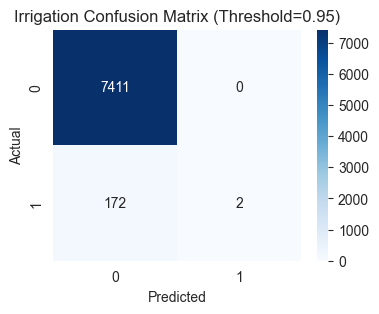

Fan actuator:
              precision    recall  f1-score   support

         0.0     0.9928    1.0000    0.9964      5795
         1.0     1.0000    0.9765    0.9881      1790

    accuracy                         0.9945      7585
   macro avg     0.9964    0.9883    0.9923      7585
weighted avg     0.9945    0.9945    0.9944      7585



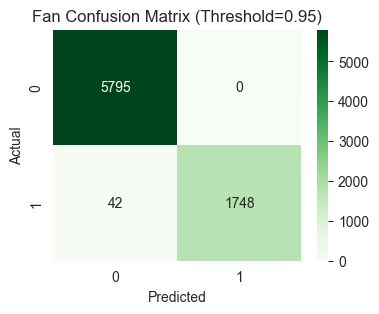


Summary of Evaluation Metrics for Each Threshold and Target:
                 Accuracy  Precision    Recall  F1-score
Irrigation_0.8   0.999868        1.0  0.994253  0.997118
Fan_0.8          0.994858        1.0  0.978212  0.988986
Irrigation_0.85  0.988794        1.0  0.511494  0.676806
Fan_0.85         0.994463        1.0  0.976536  0.988129
Irrigation_0.9   0.977456        1.0  0.017241  0.033898
Fan_0.9          0.994463        1.0  0.976536  0.988129
Irrigation_0.95  0.977324        1.0  0.011494  0.022727
Fan_0.95         0.994463        1.0  0.976536  0.988129


In [34]:
# Remove previous evaluation at threshold 0.5 and replace with 0.85, 0.9, 0.95
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

thresholds = [0.8, 0.85, 0.9, 0.95]
metrics = {}
conf_matrices = {}

# Use the baseline model's predicted probabilities for irrigation and fan
# Get predicted probabilities for each target
proba_list = time_series_model.predict_proba(X_test_processed)
proba_irrig = proba_list[0][:, 1]  # P(irrigation = 1)
proba_fan = proba_list[1][:, 1]    # P(fan = 1)

# True labels
y_true_irrig = y_test["irrigation"].values
y_true_fan = y_test["fan"].values

for thresh in thresholds:
    print(f"\n{'='*60}\nThreshold: {thresh}\n{'='*60}")
    # Irrigation
    y_pred_irrig = (proba_irrig >= thresh).astype(int)
    acc_irrig = accuracy_score(y_true_irrig, y_pred_irrig)
    prec_irrig = precision_score(y_true_irrig, y_pred_irrig)
    rec_irrig = recall_score(y_true_irrig, y_pred_irrig)
    f1_irrig = f1_score(y_true_irrig, y_pred_irrig)
    conf_irrig = confusion_matrix(y_true_irrig, y_pred_irrig)
    metrics[f'Irrigation_{thresh}'] = {'Accuracy': acc_irrig, 'Precision': prec_irrig, 'Recall': rec_irrig, 'F1-score': f1_irrig}
    conf_matrices[f'Irrigation_{thresh}'] = conf_irrig
    print("Irrigation (Water Pump):")
    print(classification_report(y_true_irrig, y_pred_irrig, digits=4))
    plt.figure(figsize=(4,3))
    sns.heatmap(conf_irrig, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Irrigation Confusion Matrix (Threshold={thresh})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    # Fan
    y_pred_fan = (proba_fan >= thresh).astype(int)
    acc_fan = accuracy_score(y_true_fan, y_pred_fan)
    prec_fan = precision_score(y_true_fan, y_pred_fan)
    rec_fan = recall_score(y_true_fan, y_pred_fan)
    f1_fan = f1_score(y_true_fan, y_pred_fan)
    conf_fan = confusion_matrix(y_true_fan, y_pred_fan)
    metrics[f'Fan_{thresh}'] = {'Accuracy': acc_fan, 'Precision': prec_fan, 'Recall': rec_fan, 'F1-score': f1_fan}
    conf_matrices[f'Fan_{thresh}'] = conf_fan
    print("Fan actuator:")
    print(classification_report(y_true_fan, y_pred_fan, digits=4))
    plt.figure(figsize=(4,3))
    sns.heatmap(conf_fan, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Fan Confusion Matrix (Threshold={thresh})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Display metrics summary table
import pandas as pd
metrics_df = pd.DataFrame(metrics).T
print("\nSummary of Evaluation Metrics for Each Threshold and Target:")
print(metrics_df)


In [35]:
# 11. Save Full Pipeline (preprocessor + model) and Config for App
import joblib
import os
import json
from sklearn.pipeline import Pipeline as SklearnPipeline

# Build a single pipeline: raw DataFrame -> preprocessor -> model (app can pipeline.predict(X_raw))
full_pipeline = SklearnPipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', time_series_model),
])
full_pipeline.fit(X_train, y_train)

print('Full pipeline created (preprocessor + multi-output model)')

# Create models directory if it doesn't exist
os.makedirs('./models', exist_ok=True)

model_path = './models/model.pkl'
joblib.dump(full_pipeline, model_path)
print(f'\nModel saved to: {model_path}')

# Config for app: feature order, targets, threshold (app applies threshold to predict_proba)
config = {
    'model_name': 'RandomForest_MultiOutput',
    'features': X.columns.tolist(),
    'targets': ['irrigation', 'fan'],
    'threshold': 0.8,
    'metrics': {
        'Irrigation_0.8': metrics.get('Irrigation_0.8', {}),
        'Fan_0.8': metrics.get('Fan_0.8', {}),
        'Irrigation_0.8': metrics.get('Irrigation_0.8', {}),
        'Fan_0.8': metrics.get('Fan_0.8', {})
    }
}
config_path = './models/config.json'
with open(config_path, 'w') as f:
    # Convert numpy/non-serializable values by making everything float
    serializable_metrics = {}
    for t, m in config['metrics'].items():
        serializable_metrics[t] = {k: (float(v) if not isinstance(v, (np.ndarray, list, dict)) else v)
                                   for k, v in m.items()}
    config_safe = {**config, 'metrics': serializable_metrics}
    json.dump(config_safe, f, indent=2)
print(f'Config saved to: {config_path}')

Full pipeline created (preprocessor + multi-output model)

Model saved to: ./models/model.pkl
Config saved to: ./models/config.json


In [36]:
# 10c. Evaluation: Noisy-Training Model on Clean Test Set
from sklearn.metrics import classification_report

# Train a noisy model if not already defined
if 'time_series_model_noisy' not in globals():
    # Preprocess noisy training features
    X_train_processed_noisy = preprocessor.fit_transform(X_train_noisy)
    X_test_processed_noisy = preprocessor.transform(X_test)
    # Train model
    base_clf_noisy = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    time_series_model_noisy = MultiOutputClassifier(base_clf_noisy)
    time_series_model_noisy.fit(X_train_processed_noisy, y_train)

# Predict on the clean time-based test set using the noisy-trained model
y_pred_noisy = time_series_model_noisy.predict(X_test_processed_noisy)

# Split predictions by target
y_pred_irrigation_noisy = y_pred_noisy[:, 0]
y_pred_fan_noisy = y_pred_noisy[:, 1]

print("=== Irrigation (Water Pump) – noisy training ===")
print(classification_report(y_test["irrigation"], y_pred_irrigation_noisy, digits=4))

print("=== Fan Actuator – noisy training ===")
print(classification_report(y_test["fan"], y_pred_fan_noisy, digits=4))


=== Irrigation (Water Pump) – noisy training ===
              precision    recall  f1-score   support

         0.0     0.9950    1.0000    0.9975      7411
         1.0     1.0000    0.7874    0.8810       174

    accuracy                         0.9951      7585
   macro avg     0.9975    0.8937    0.9393      7585
weighted avg     0.9951    0.9951    0.9948      7585

=== Fan Actuator – noisy training ===
              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000      5795
         1.0     1.0000    1.0000    1.0000      1790

    accuracy                         1.0000      7585
   macro avg     1.0000    1.0000    1.0000      7585
weighted avg     1.0000    1.0000    1.0000      7585



### Interpretation

- The **baseline model** was trained on clean data and evaluated on a clean time-based test set.
- The **noisy model** was trained on data where ~10% of training rows had their sensor/time features randomly perturbed, but still evaluated on the same clean test set.
- Comparing the metrics (especially accuracy and F1) between the two versions shows how robust the irrigation and fan predictions are to noisy training data.